# Reinforcement Learning

## Frozen Lake

from: https://www.gymlibrary.dev/environments/toy_text/frozen_lake/

![frozen lake](https://www.gymlibrary.dev/_images/frozen_lake.gif)


### Description

Frozen lake involves crossing a frozen lake from Start(S) to Goal(G) without falling into any Holes(H) by walking over the Frozen(F) lake. The agent may not always move in the intended direction due to the slippery nature of the frozen lake.


### Actions

The agent takes a 1-element vector for actions. The action space is (dir), where dir decides direction to move in which can be:

    0: LEFT
    1: DOWN
    2: RIGHT
    3: UP


### Observations

The observation is a value representing the agent’s current position as current_row * nrows + current_col (where both the row and col start at 0). For example, the goal position in the 4x4 map can be calculated as follows: 3 * 4 + 3 = 15. The number of possible observations is dependent on the size of the map. For example, the 4x4 map has 16 possible observations.


### Rewards

    Reach goal(G): +1
    Reach hole(H): 0
    Reach frozen(F): 0


### Install dependencies if needed
The following command will allow you to install gym, which is a toolkit for developing and comparing reinforcement learning algorithms: https://gym.openai.com/


pip install --upgrade git+https://github.com/openai/gym

### Import packages

In [1]:
import gym
from IPython.display import clear_output
from time import sleep
import numpy as np
from matplotlib import pyplot as pl

In [2]:
env = gym.make('FrozenLake-v1',
               desc=None,
               map_name='4x4',
               render_mode='ansi',
               is_slippery=False).env

In [3]:
if False:                          # change this to True if you want to create a 5x5 environment
    env = gym.make('FrozenLake-v1',
                   desc=gym.envs.toy_text.frozen_lake.generate_random_map(size=5),
                   map_name='5x5',
                   render_mode='ansi',
                   is_slippery=False).env

In [4]:
def print_frames(frames):
    for i, frame in enumerate(frames):
        clear_output(wait=True)
        print(frame['frame'])
        print(f'Timestep: {i + 1}')
        print(f"State: {frame['state']}")
        print(f"Action: {frame['action']}")
        print(f"Reward: {frame['reward']}")
        sleep(.1)

def argmax_choice(b):
    return np.random.choice(np.flatnonzero(b == b.max()))


# Brute force

First, let's test how much time it takes to an agent performing random actions to complete the task

In [5]:
state, _ = env.reset()  # set environment to illustration's state

epochs = 0
reward = 0

frames = [] # for animation

done = False

while reward == 0:
    action = env.action_space.sample()
    state, reward, done, _, _ = env.step(action)

    # Put each rendered frame into dict for animation
    frames.append({
        'frame': env.render(),
        'state': state,
        'action': action,
        'reward': reward
        }
    )

    epochs += 1
    
    if done:
        state, _ = env.reset()
    
print('Timesteps taken: {}'.format(epochs))
        
print_frames(frames)


  (Right)
SFFF
FHFH
FFFH
HFFG

Timestep: 1161
State: 15
Action: 2
Reward: 1.0


# Q-learning
Now, let's use reinforcemet learning to solve the task

In [15]:
actions_dict = {0:'left',
                1:'down',
                2:'right',
                3:'up'}

In [16]:
q_table = np.zeros([env.observation_space.n, env.action_space.n])

q_table.shape

(16, 4)

## Visualizing the Q table before learning

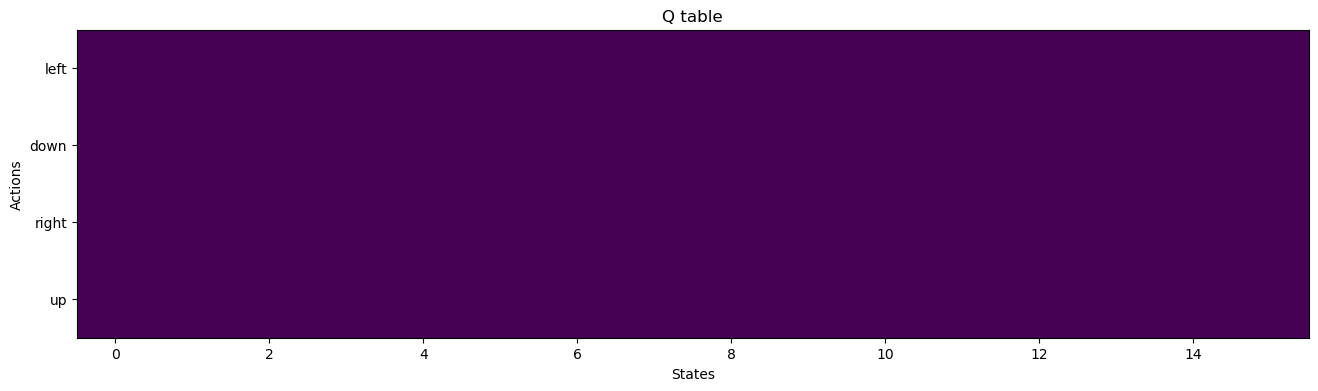

In [17]:
def show_q_table(table, binary=False):
    pl.figure(figsize=(16,4))
    
    if binary:
        temp = np.zeros(table.shape)
        for i,j in enumerate(np.argmax(table, axis=1)):
            temp[i,j] = 1
        pl.imshow(temp.T, interpolation='nearest', aspect=1)
    else:
        pl.imshow(table.T, interpolation='nearest', aspect=1)
    
    pl.yticks(range(len(actions_dict)), [actions_dict[k] for k in range(len(actions_dict))])
    pl.title('Q table')
    pl.xlabel('States')
    pl.ylabel('Actions')

show_q_table(q_table)

Episode: 10000
Training finished.

CPU times: total: 7.45 s
Wall time: 8.14 s


Text(0, 0.5, 'Somme des rewards sur 100 itérations')

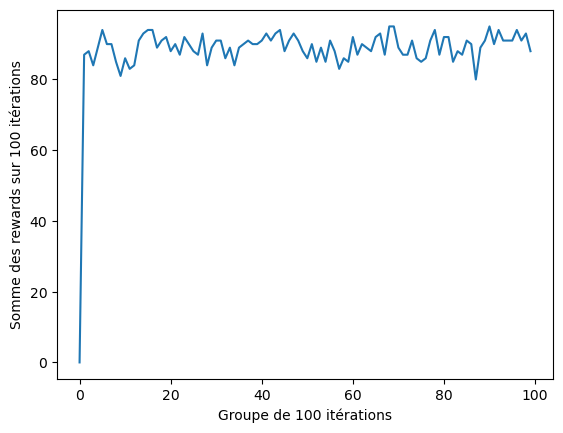

In [18]:
%%time

import matplotlib.pyplot as plt

print('Training the agent')

# Hyperparameters
alpha = 0.1
gamma = 0.6
epsilon = 0.1

# For plotting metrics
plot_data = []

N_EPISODES = 100

def choose_next_action(q_table, state):
    if np.random.uniform(0, 1) < epsilon:
        return env.action_space.sample() # Explore action space
    return argmax_choice(q_table[state,:]) # Exploit learned values

for i in range(1, 10001):
    state, _ = env.reset()

    epochs, reward, = 0, 0
    done = False
    
    while not done:
        action = choose_next_action(q_table, state)

        next_state, reward, done, _, _ = env.step(action)
        
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state,:])
        
        new_value = ((1 - alpha) * old_value) + (alpha * (reward + gamma * next_max))
        q_table[state, action] = new_value

        state = next_state
        epochs += 1
        
    if i % 100 == 0:
        clear_output(wait=True)
        print(f'Episode: {i}')

        total_wins = 0
        for _ in range(N_EPISODES):
            state, _ = env.reset()
            reward = 0
            
            done = False
            while not done:
                action = choose_next_action(q_table, state)
                state, reward, done, _, _ = env.step(action)

                if reward != 0:
                    total_wins += 1

        plot_data.append(total_wins)

print('Training finished.\n')
plt.plot(plot_data)
plt.xlabel('Groupe de 100 itérations')
plt.ylabel('Somme des rewards sur 100 itérations')


## Visualizing the Q table after learning

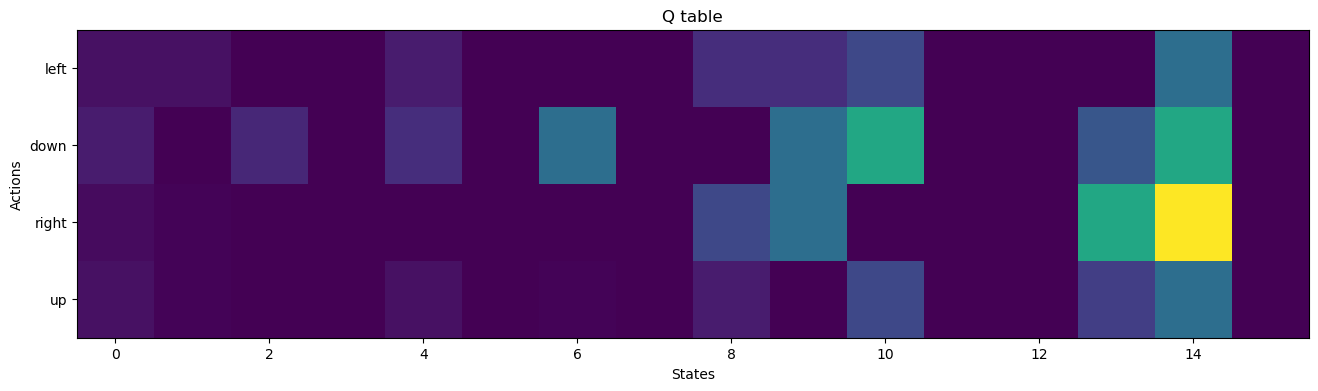

In [19]:
show_q_table(q_table)

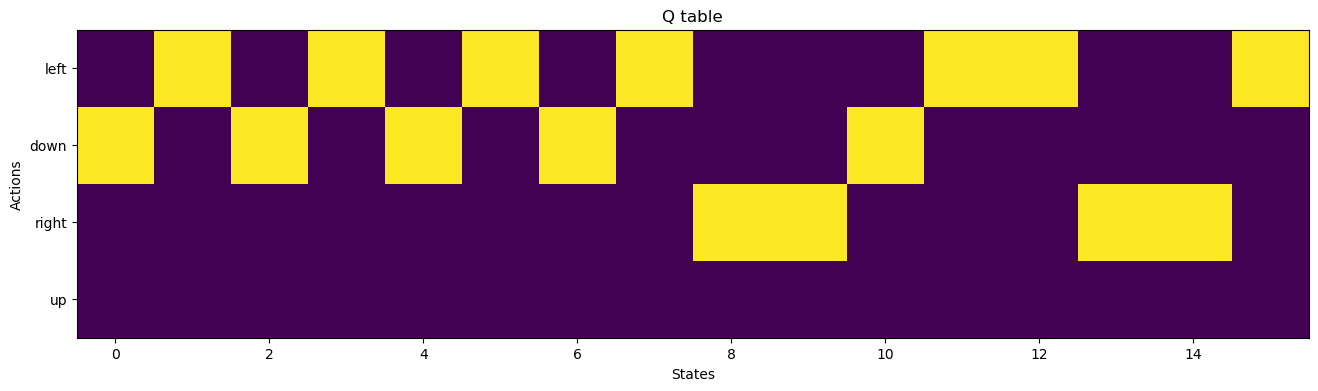

In [20]:
show_q_table(q_table, binary=True)

## Evaluate agent's performance after Q-learning

In [21]:
total_epochs = 0
episodes = 100

for _ in range(episodes):
    state, _ = env.reset()
    epochs, reward = 0, 0
    
    done = False
    
    while not done:
        action = argmax_choice(q_table[state,:])
        state, reward, done, _, _ = env.step(action)

        epochs += 1

    total_epochs += epochs

print(f'Results after {episodes} episodes:')
print(f'Average timesteps per episode: {total_epochs / episodes}')


Results after 100 episodes:
Average timesteps per episode: 6.0


## Visualizing an individual episode

In [22]:
state, _ = env.reset()
epochs, reward = 0, 0

done = False

while not done:
    action = argmax_choice(q_table[state,:])
    state, reward, done, _, _ = env.step(action)

    epochs += 1
    
    clear_output(wait=True)
    print(env.render())
    sleep(.2)

print(f'Timesteps: {epochs}')


  (Right)
SFFF
FHFH
FFFH
HFFG

Timesteps: 6


----------

## Analysis

Look at the foollowing image and try to understand how it was done.

Do you think that the behavior of the agent is correct?

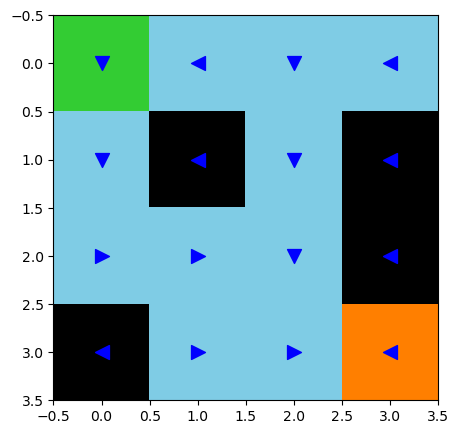

In [23]:
actions_dict_arrows = {0:'<',
                       1:'v',
                       2:'>',
                       3:'^'}

obs_dict = {b'S': [0.2, 0.8, 0.2],  # start
            b'F': [0.5, 0.8, 0.9],  # frozen
            b'H': [0, 0, 0],        # hole
            b'G': [1, 0.5, 0]}      # goal

positions = np.zeros((env.nrow*env.ncol, 2))
markers = []
frozen_lake = np.zeros((env.nrow, env.ncol, 3))

for current_row in range(env.nrow):
    for current_col in range(env.ncol):
        frozen_lake[current_row, current_col, :] = obs_dict[env.desc[current_row, current_col]]
        positions[current_row * env.nrow + current_col,0] = current_col
        positions[current_row * env.nrow + current_col,1] = current_row
        markers.append(actions_dict_arrows[np.argmax(q_table[current_row * env.nrow + current_col,:])])

pl.figure(figsize=(5,5))
pl.imshow(frozen_lake, origin='upper')
for x, y, m in zip(positions[:,0], positions[:,1], markers):
    pl.scatter(x, y, marker=m, c='b', s=100)


### Test the reinforcement learning strategy on a bigger environment: 5x5